# Reproduce the figures and headline statistics

This notebook reproduces **Figure 2**, **Supplementary Figure S1**, and **Supplementary Figure S2** of *Closing the freshwater verification gap* (Perspective, submitted to *Nature Water*), plus every numerical claim in the abstract and main text that is derived from the figures.

**Prerequisites.** The notebook depends only on `pandas`, `matplotlib`, and `numpy`, pinned to the versions in `requirements.txt`. All source data lives in `figure_data/` as tidy CSV files; no network calls are made at notebook runtime.

**Launching in Binder.** Click the Binder badge in the README and wait roughly ninety seconds for the environment to build. Then open this notebook from the file browser on the left and choose **Run All** from the **Run** menu.

**Outputs.** Every plot below matches the version embedded in the submitted manuscript. Pixel-level differences, if any, come from matplotlib version differences across the bundled `plot_fig2_combined.py`, `plot_networks_landscape.py`, and `plot_supp_fig_s2_annual.py` scripts that this notebook calls.

## 1. Setup and data inventory

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

DATA = Path('figure_data')
assert DATA.is_dir(), 'Run the notebook from the repository root so figure_data/ resolves.'

expected_csvs = [
    'neon_aquatic_sites.csv',
    'ilter_sites.csv',
    'tedesco_basin_richness.csv',
    'gbif_country_effort.csv',
    'panel_b_timescales.csv',
    'scissors_publications_by_year.csv',
    'networks_landscape.csv',
]
for name in expected_csvs:
    path = DATA / name
    if path.exists():
        print(f'ok   {name:45s} {path.stat().st_size:>10,} bytes')
    else:
        print(f'MISS {name}')

ok   neon_aquatic_sites.csv                             3,579 bytes
ok   ilter_sites.csv                                  177,036 bytes
ok   tedesco_basin_richness.csv                       154,416 bytes
ok   gbif_country_effort.csv                            4,539 bytes
ok   panel_b_timescales.csv                             4,482 bytes
ok   scissors_publications_by_year.csv                  3,824 bytes
ok   networks_landscape.csv                             2,817 bytes


## 2. Headline statistics used in the abstract, main text, and figure captions

In [2]:
neon = pd.read_csv(DATA / 'neon_aquatic_sites.csv')
ilter = pd.read_csv(DATA / 'ilter_sites.csv')
tedesco = pd.read_csv(DATA / 'tedesco_basin_richness.csv')
scissors = pd.read_csv(DATA / 'scissors_publications_by_year.csv')

print('NEON aquatic sites (all biomes):', len(neon))
ilter_aq = ilter[ilter['is_aquatic_by_name'] == True]
print('ILTER aquatic sites:            ', len(ilter_aq))
tedesco_plot = tedesco.dropna(subset=['latitude', 'longitude'])
tedesco_plot = tedesco_plot[tedesco_plot['native_richness'] > 0]
print(f'Tedesco basins archived:         {len(tedesco):,}')
print(f'Tedesco basins plotted in Fig 2A:{len(tedesco_plot):,} (after filtering to rows with outlet coordinates)')

high_rich = tedesco_plot[tedesco_plot['native_richness'] >= 200]
tropical = high_rich[high_rich['latitude'].between(-23.5, 23.5)]
print(f'High-richness basins (>=200 native spp): {len(high_rich):,}')
print(f'  of which tropical: {len(tropical):,} ({100 * len(tropical) / len(high_rich):.0f}%)')

NEON aquatic sites (all biomes): 34
ILTER aquatic sites:             205
Tedesco basins archived:         3,119
Tedesco basins plotted in Fig 2A:2,898 (after filtering to rows with outlet coordinates)
High-richness basins (>=200 native spp): 41
  of which tropical: 33 (80%)


In [3]:
# Bibliometric divergence: OpenAlex scissors (Figure 2C)
def growth(query):
    sub = scissors[scissors['query'] == query].sort_values('year')
    y0 = sub[sub['year'] == 2000]['n_works'].iloc[0]
    y1 = sub[sub['year'] == 2025]['n_works'].iloc[0]
    return y0, y1, y1 / y0

for q in scissors['query'].unique():
    y0, y1, fold = growth(q)
    print(f'{q:32s}  2000: {y0:>6,}/yr   2025: {y1:>6,}/yr   fold-change: {fold:,.0f}x')

freshwater_ml                     2000:     42/yr   2025:  8,558/yr   fold-change: 204x
freshwater_model                  2000:  1,122/yr   2025: 29,541/yr   fold-change: 26x
freshwater_monitoring             2000:    633/yr   2025:  8,940/yr   fold-change: 14x
freshwater_prediction             2000:    639/yr   2025: 14,635/yr   fold-change: 23x


## 3. Figure 2, main text

Three panels in a single composite: **(A)** map of NEON plus ILTER aquatic sites over native fish-richness basins; **(B)** variable dynamics versus sampling frequencies on a log time axis; **(C)** cumulative publication scissors plot for four OpenAlex queries.

wrote fig2_v40.png


wrote fig2_v40.svg

Headline statistics used in the caption:
  Tedesco basins plotted: 2,898
  High-richness basins (>=200): 41; tropical: 80%
  NEON sites plotted: 34
  ILTER aquatic sites: 205
  ML annual rate: 42/yr (2000) -> 8,558/yr (2025); fold change 204x
  Monitoring annual rate: 633/yr (2000) -> 8,940/yr (2025); fold change 14x


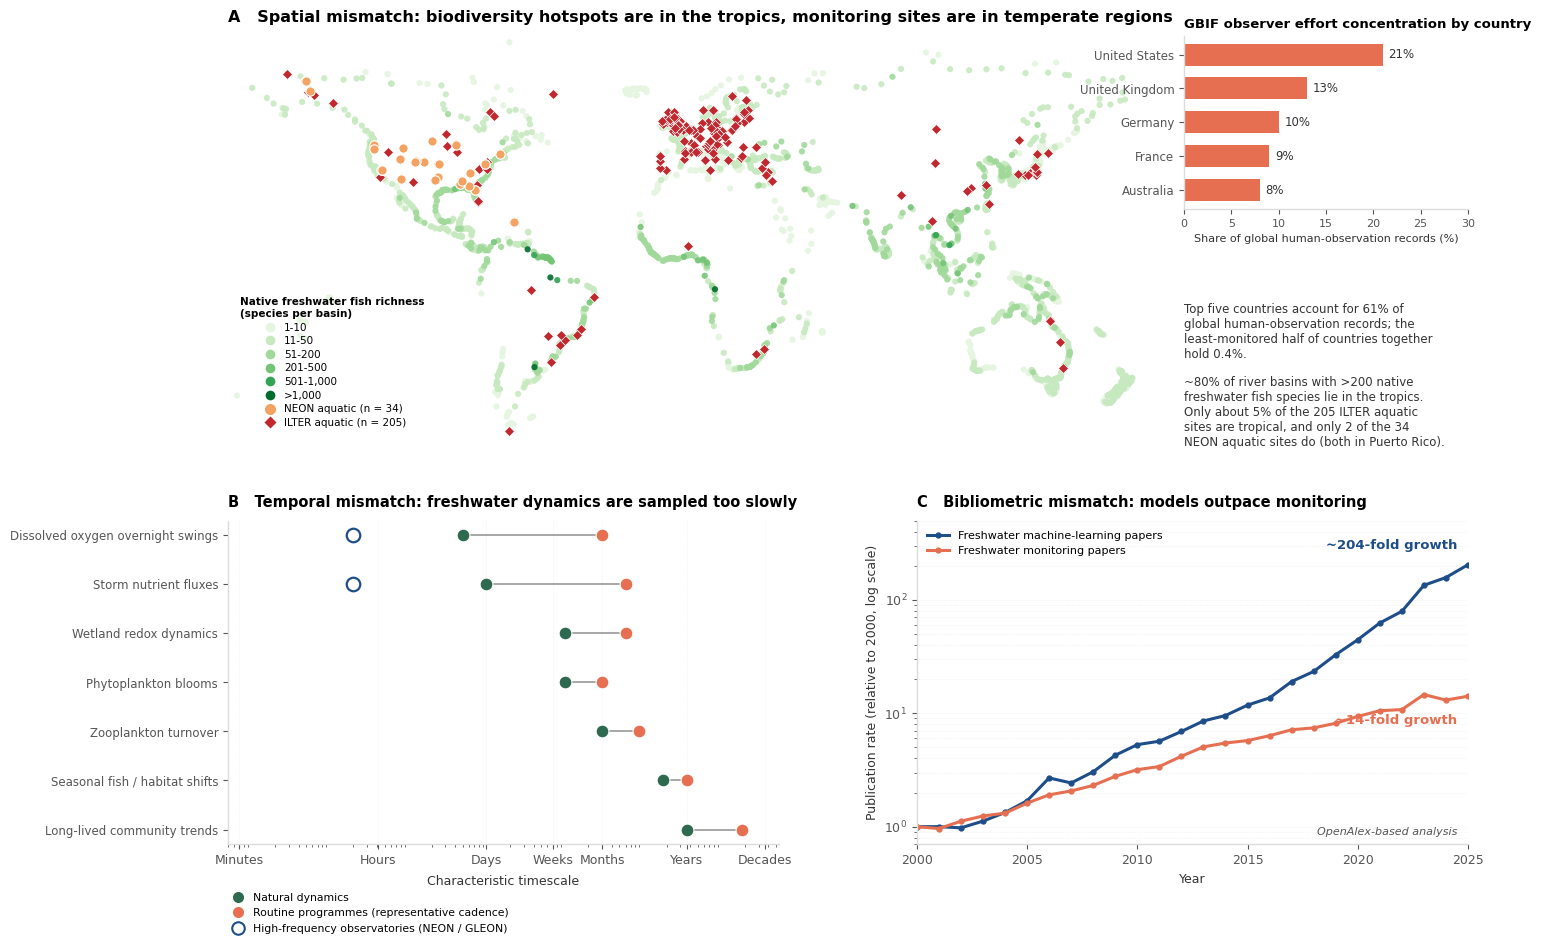

In [4]:
%run figure_data/plot_fig2_combined.py

## 4. Supplementary Figure S1, monitoring networks landscape

Thirty-two active freshwater monitoring networks plotted in frequency by coverage space. This is a curated cross-section rather than an exhaustive list.

wrote networks_landscape.png
wrote networks_landscape.svg


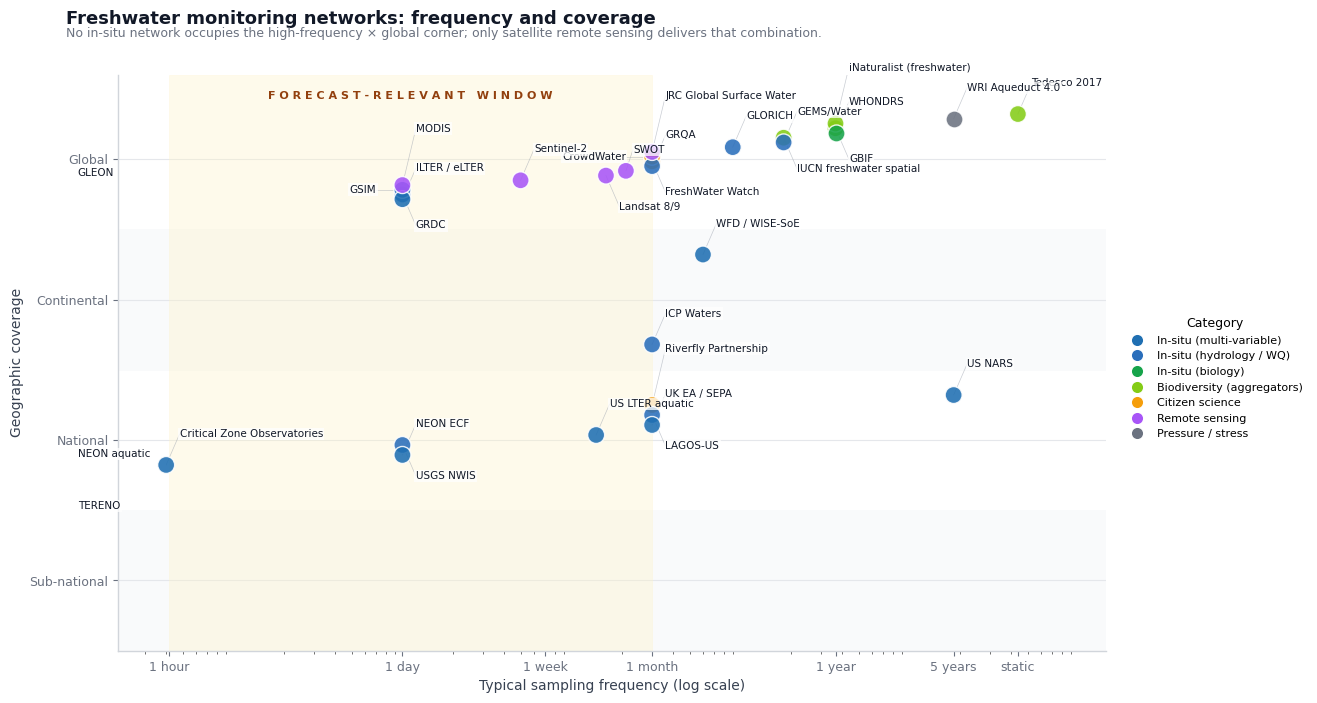

In [5]:
%run figure_data/plot_networks_landscape.py

## 5. Supplementary Figure S2, annual counts robustness

Figure 2C uses cumulative counts on a logarithmic y-axis. This figure re-plots the same data as annual counts in both linear and log forms, confirming that the widening divergence is present year by year and not an artefact of cumulation.

wrote supplementary_figure_s2.png
wrote supplementary_figure_s2.svg


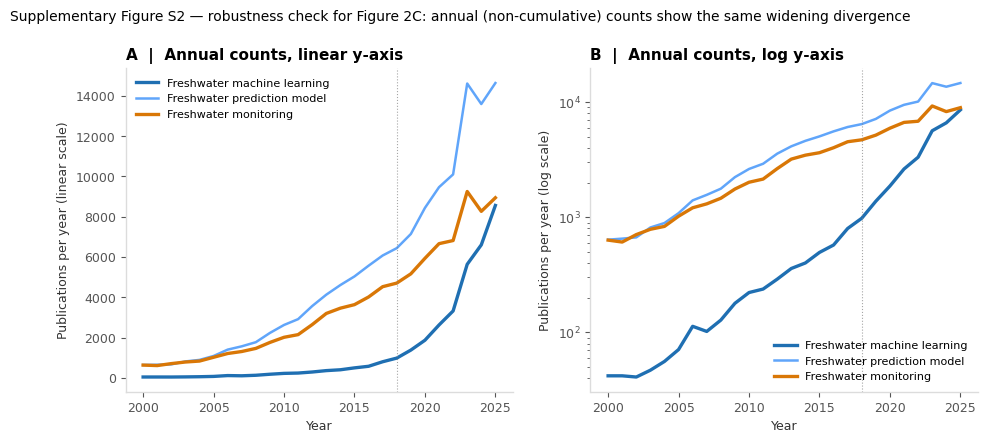

In [6]:
%run figure_data/plot_supp_fig_s2_annual.py

## 6. Provenance

All datasets used above are public and licensed for redistribution:

| Dataset | Source | Licence |
|---|---|---|
| NEON aquatic sites | data.neonscience.org | CC0 |
| ILTER via DEIMS-SDR | deims.org | CC BY |
| GBIF country aggregates | gbif.org | CC BY |
| Tedesco *et al.* 2017 | figshare 5245072 | CC0 |
| WRI Aqueduct 4.0 | wri.org/aqueduct | CC BY 4.0 |
| OpenAlex works by year | api.openalex.org | CC0 |

The extraction scripts that produced the tidy CSVs in `figure_data/` are in the same folder. Run `make` (or inspect the `Makefile`) to rebuild any CSV from its upstream source.